In [2]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [3]:
import pandas as pd
import os

csv_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())

print("\nData info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nChurn distribution:")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3))

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nul

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df.isnull().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df = df.drop("customerID", axis=1)

df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

print("Cleaning complete")
df.head()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
Cleaning complete


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [6]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X = pd.get_dummies(X, drop_first=True)

print("\nEncoded feature shape:", X.shape)


Encoded feature shape: (7043, 30)


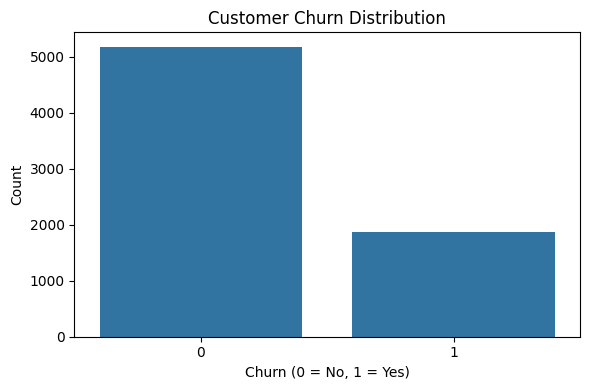

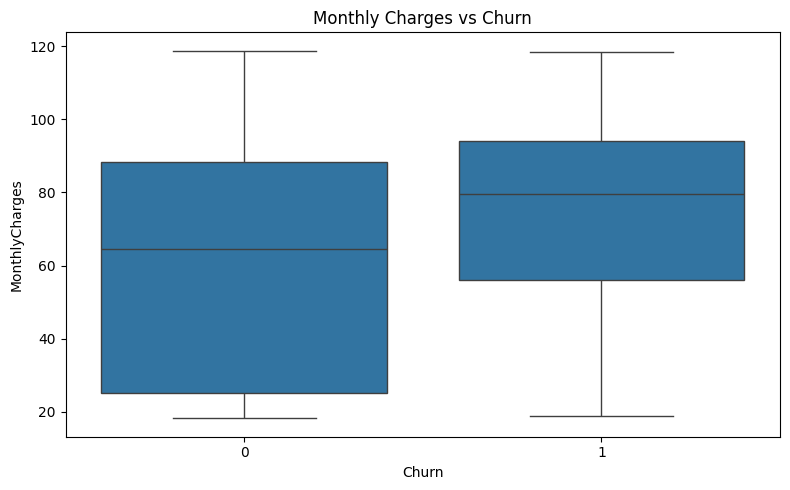

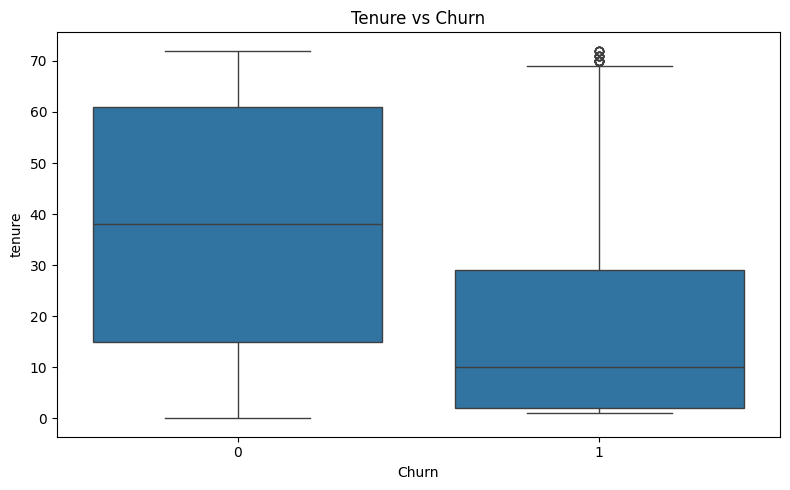

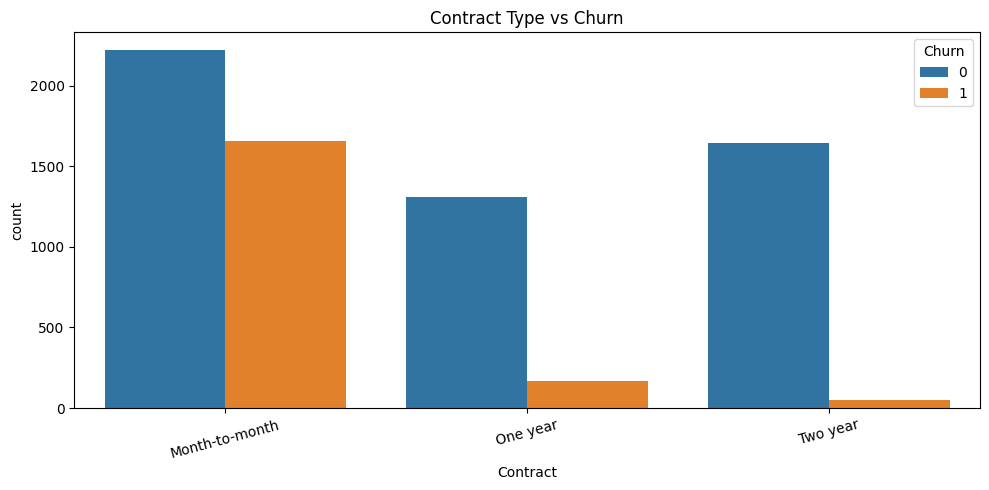

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))
print("PR AUC:", average_precision_score(y_test, y_prob_log))


=== Logistic Regression ===
Confusion Matrix:
 [[925 110]
 [162 212]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC AUC: 0.8415846443979436
PR AUC: 0.6321554825566654


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n=== Random Forest ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR AUC:", average_precision_score(y_test, y_prob_rf))


=== Random Forest ===
Confusion Matrix:
 [[943  92]
 [181 193]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409

ROC AUC: 0.8433800924849518
PR AUC: 0.657265498196392


In [11]:
from sklearn.metrics import precision_recall_curve
import numpy as np

def best_f1_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = (2 * precision * recall) / (precision + recall + 1e-12) # Add small epsilon to avoid division by zero
    best_idx = np.argmax(f1_scores[:-1]) # Exclude last threshold, as it's always 1.0
    return thresholds[best_idx]

thr_log = best_f1_threshold(y_test, y_prob_log)
y_pred_log_thr = (y_prob_log >= thr_log).astype(int)

print(f"\n=== Logistic Regression Tuned Threshold ({thr_log:.4f}) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_thr))
print(classification_report(y_test, y_pred_log_thr))

thr_rf = best_f1_threshold(y_test, y_prob_rf)
y_pred_rf_thr = (y_prob_rf >= thr_rf).astype(int)

print(f"\n=== Random Forest Tuned Threshold ({thr_rf:.4f}) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_thr))
print(classification_report(y_test, y_pred_rf_thr))


=== Logistic Regression Tuned Threshold (0.2745) ===
Confusion Matrix:
 [[762 273]
 [ 82 292]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409


=== Random Forest Tuned Threshold (0.2823) ===
Confusion Matrix:
 [[765 270]
 [ 76 298]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



### 11) ROC + Precision-Recall Curves

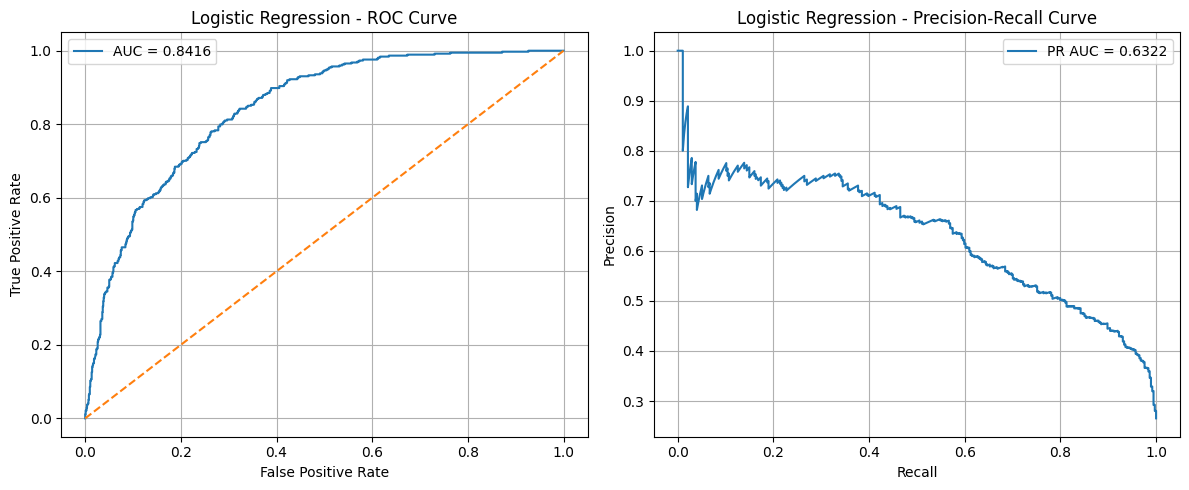

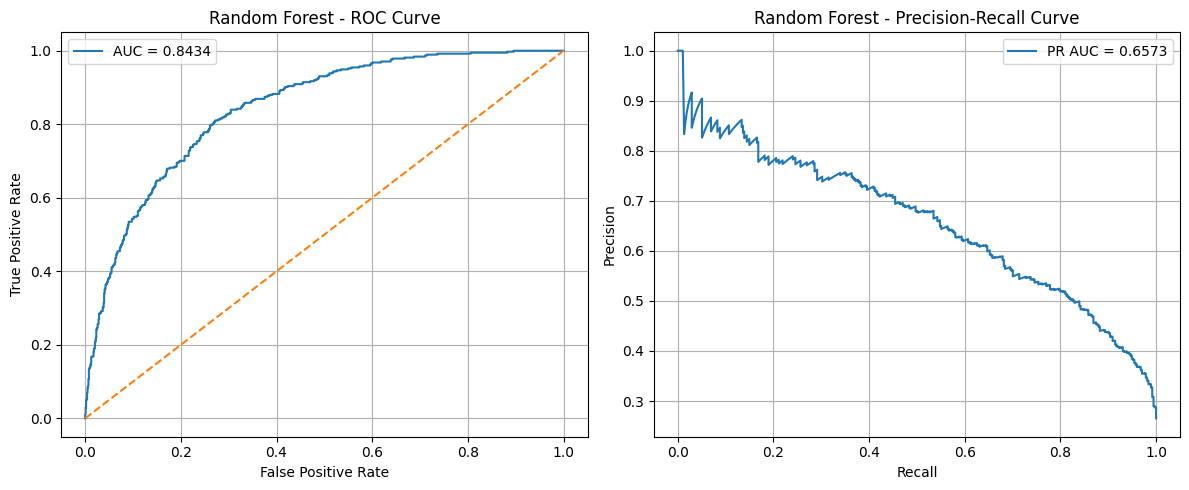

In [12]:
from sklearn.metrics import roc_curve, auc, average_precision_score
import matplotlib.pyplot as plt

def plot_roc_pr(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    plt.figure(figsize=(12,5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{model_name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_roc_pr(y_test, y_prob_log, "Logistic Regression")
plot_roc_pr(y_test, y_prob_rf, "Random Forest")

### 12) Feature Importance (Random Forest)


Top 15 Most Important Features:


,feature,importance
1,tenure,0.191994
3,TotalCharges,0.156793
2,MonthlyCharges,0.114299
10,InternetService_Fiber optic,0.069463
25,Contract_Two year,0.065232
28,PaymentMethod_Electronic check,0.061970
13,OnlineSecurity_Yes,0.037972
24,Contract_One year,0.034490
19,TechSupport_Yes,0.022729
26,PaperlessBilling_Yes,0.021772


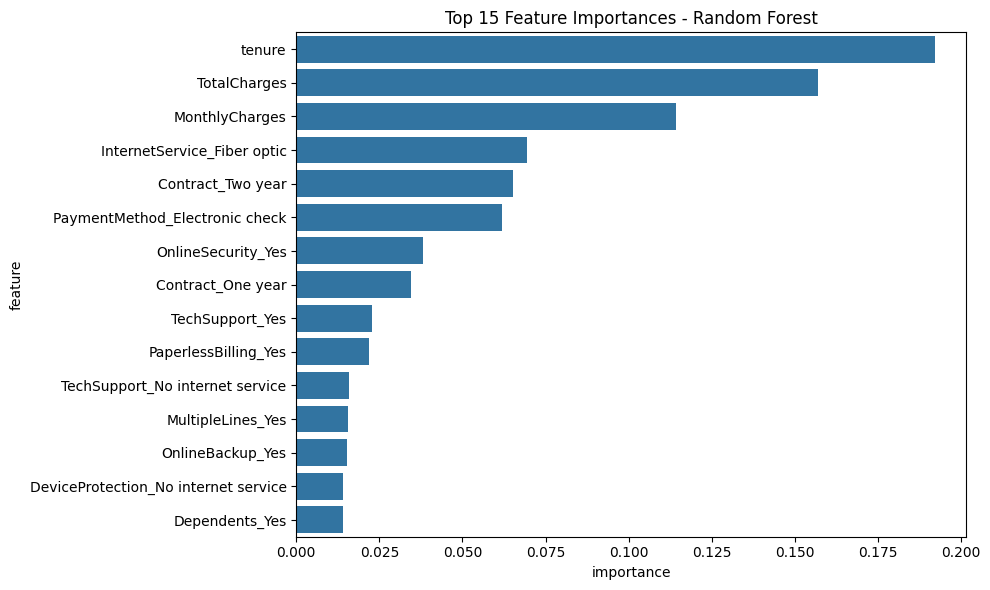

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 Most Important Features:")
display(feature_importance.head(15))

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Classifier ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR AUC:", average_precision_score(y_test, y_prob_xgb))

Scale Pos Weight: 2.77

=== XGBoost Classifier ===
Confusion Matrix:
 [[810 225]
 [114 260]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC AUC: 0.8315675940995633
PR AUC: 0.6352254299767381


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:47:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [15]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss', # Suppress warning
    scale_pos_weight=scale_pos_weight
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Classifier ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR AUC:", average_precision_score(y_test, y_prob_xgb))

Scale Pos Weight: 2.77

=== XGBoost Classifier ===
Confusion Matrix:
 [[810 225]
 [114 260]]
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409

ROC AUC: 0.8315675940995633
PR AUC: 0.6352254299767381


In [17]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos
print(f"Scale Pos Weight: {scale_pos_weight:.2f}")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1', # Using f1 score for imbalanced data
    cv=3, # Using 3-fold cross-validation
    verbose=1,
    n_jobs=-1 # Use all available cores
)

grid_search.fit(X_train, y_train)

print("\nBest parameters found:", grid_search.best_params_)
print("Best F1-score found:", grid_search.best_score_)

best_xgb_model = grid_search.best_estimator_
print("\nBest XGBoost model stored.")

Scale Pos Weight: 2.77
Fitting 3 folds for each of 729 candidates, totalling 2187 fits

Best parameters found: {'colsample_bytree': 0.7, 'gamma': 0.2, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.7}
Best F1-score found: 0.6389739972501371

Best XGBoost model stored.


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score
import numpy as np

y_pred_xgb_tuned = best_xgb_model.predict(X_test)
y_prob_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

print("\n=== Tuned XGBoost Classifier ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_tuned))
print(classification_report(y_test, y_pred_xgb_tuned))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb_tuned))
print("PR AUC:", average_precision_score(y_test, y_prob_xgb_tuned))

thr_xgb = best_f1_threshold(y_test, y_prob_xgb_tuned)
y_pred_xgb_thr_tuned = (y_prob_xgb_tuned >= thr_xgb).astype(int)

print(f"\n=== Tuned XGBoost Classifier Tuned Threshold ({thr_xgb:.4f}) ===")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_thr_tuned))
print(classification_report(y_test, y_pred_xgb_thr_tuned))


=== Tuned XGBoost Classifier ===
Confusion Matrix:
 [[758 277]
 [ 77 297]]
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC AUC: 0.8456896329019092
PR AUC: 0.6634482387635523

=== Tuned XGBoost Classifier Tuned Threshold (0.5903) ===
Confusion Matrix:
 [[820 215]
 [ 99 275]]
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.74      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



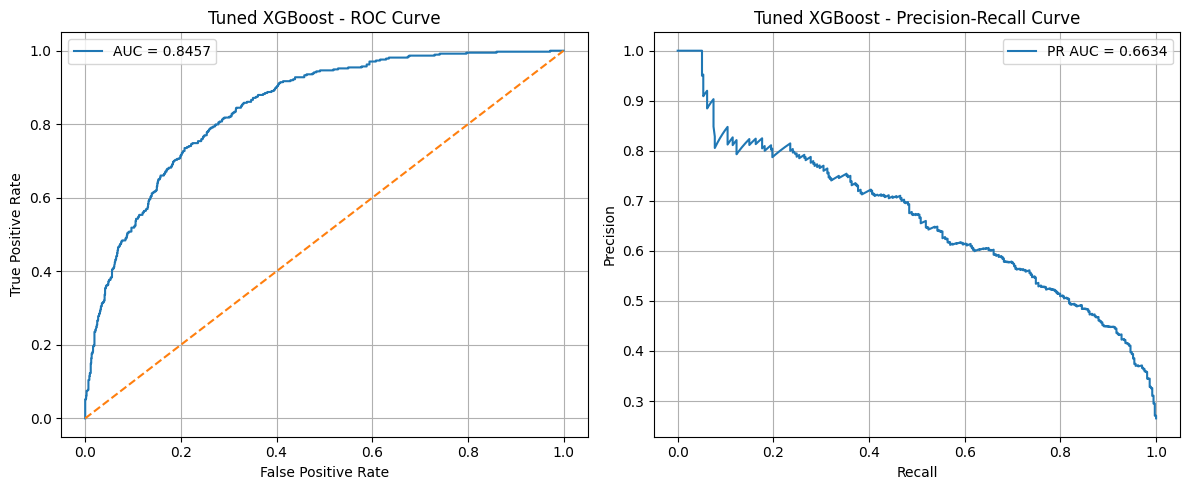

In [19]:
plot_roc_pr(y_test, y_prob_xgb_tuned, "Tuned XGBoost")


Top 15 Most Important Features (Tuned XGBoost):


,feature,importance
25,Contract_Two year,0.200855
10,InternetService_Fiber optic,0.123675
24,Contract_One year,0.098911
14,OnlineBackup_No internet service,0.069049
11,InternetService_No,0.058101
16,DeviceProtection_No internet service,0.057858
28,PaymentMethod_Electronic check,0.050647
12,OnlineSecurity_No internet service,0.049812
1,tenure,0.028799
23,StreamingMovies_Yes,0.027031


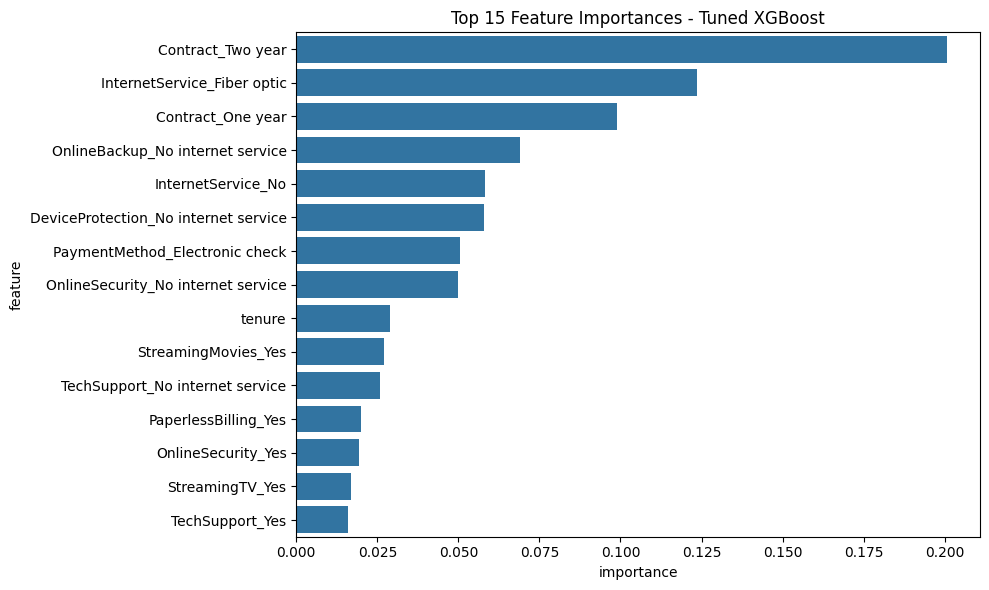

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_importance_xgb = pd.DataFrame({
    "feature": X.columns,
    "importance": best_xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 Most Important Features (Tuned XGBoost):")
display(feature_importance_xgb.head(15))

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance_xgb.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances - Tuned XGBoost")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve, f1_score
import numpy as np

def get_model_metrics(model_name, y_true, y_pred, y_prob):
    def best_f1_threshold(y_true, y_prob):
        precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
        f1_scores = (2 * precision * recall) / (precision + recall + 1e-12)
        best_idx = np.argmax(f1_scores[:-1])
        return thresholds[best_idx]

    cm = confusion_matrix(y_true, y_pred)

    report = classification_report(y_true, y_pred, output_dict=True)

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    tuned_threshold = best_f1_threshold(y_true, y_prob)
    y_pred_tuned_thr = (y_prob >= tuned_threshold).astype(int)
    cm_tuned = confusion_matrix(y_true, y_pred_tuned_thr)
    report_tuned = classification_report(y_true, y_pred_tuned_thr, output_dict=True)

    metrics = {
        "model_name": model_name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "f1_churn_default": report["1"]["f1-score"],
        "precision_churn_default": report["1"]["precision"],
        "recall_churn_default": report["1"]["recall"],
        "tuned_threshold": tuned_threshold,
        "f1_churn_tuned": report_tuned["1"]["f1-score"],
        "precision_churn_tuned": report_tuned["1"]["precision"],
        "recall_churn_tuned": report_tuned["1"]["recall"]
    }
    return metrics

print("Helper function `get_model_metrics` defined.")

Helper function `get_model_metrics` defined.


In [22]:
metrics_log_reg = get_model_metrics(
    "Logistic Regression", y_test, y_pred_log, y_prob_log
)
metrics_rf = get_model_metrics("Random Forest", y_test, y_pred_rf, y_prob_rf)
metrics_xgb_tuned = get_model_metrics(
    "Tuned XGBoost", y_test, y_pred_xgb_tuned, y_prob_xgb_tuned
)

all_model_metrics = [metrics_log_reg, metrics_rf, metrics_xgb_tuned]

print("Metrics collected for all models.")

Metrics collected for all models.


In [23]:
import pandas as pd

metrics_df = pd.DataFrame(all_model_metrics)

print("\n--- Model Performance Comparison ---")
display(metrics_df.set_index("model_name").round(4))


--- Model Performance Comparison ---


,roc_auc,pr_auc,f1_churn_default,precision_churn_default,recall_churn_default,tuned_threshold,f1_churn_tuned,precision_churn_tuned,recall_churn_tuned
model_name,,,,,,,,,
Logistic Regression,0.8416,0.6322,0.6092,0.6584,0.5668,0.2745,0.6219,0.5168,0.7807
Random Forest,0.8434,0.6573,0.5857,0.6772,0.5160,0.2823,0.6327,0.5246,0.7968
Tuned XGBoost,0.8457,0.6634,0.6266,0.5174,0.7941,0.5903,0.6366,0.5612,0.7353


In [24]:
pip install shap

SHAP values calculated.


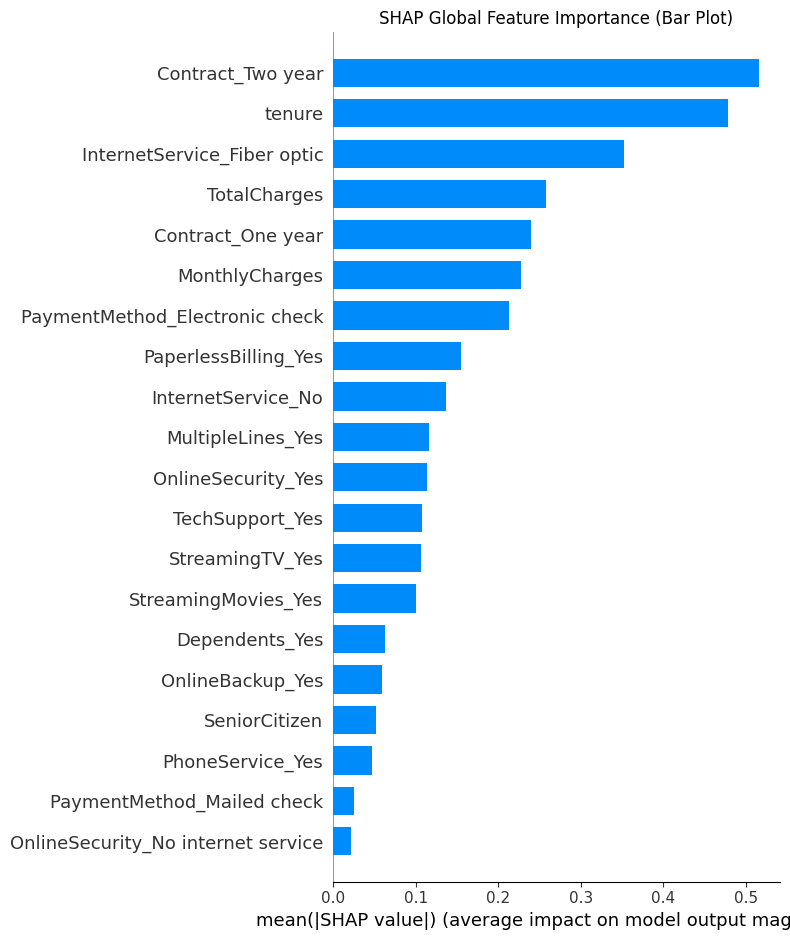

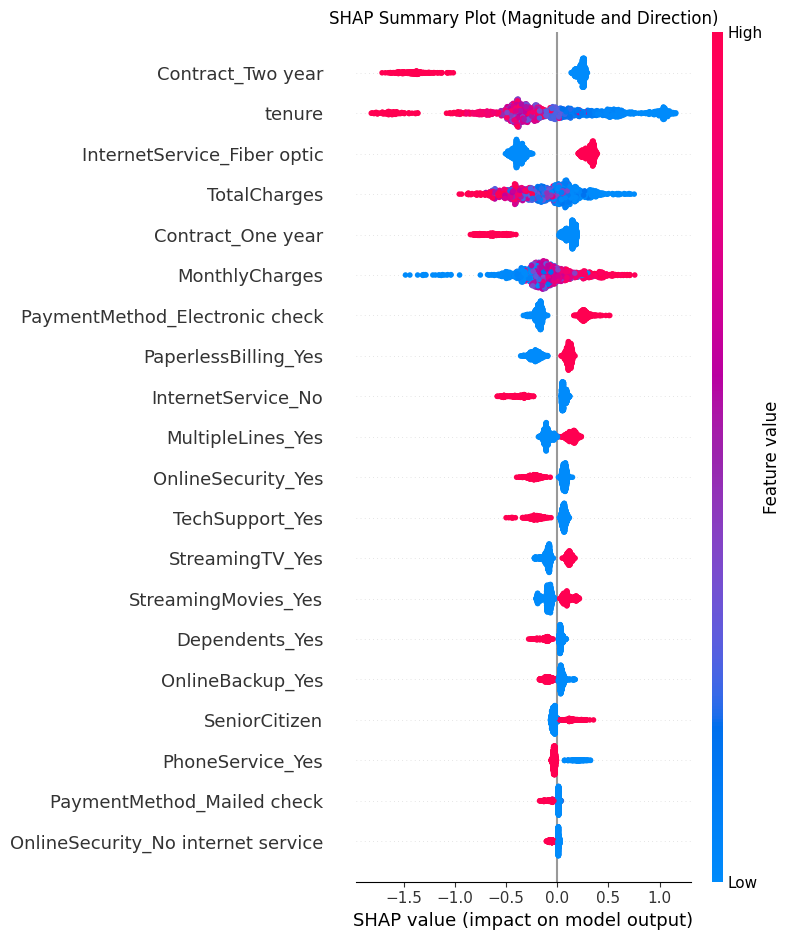

In [25]:
import shap
import matplotlib.pyplot as plt

# Create a SHAP TreeExplainer object for the best_xgb_model
explainer = shap.TreeExplainer(best_xgb_model)

# Calculate SHAP values for the X_test dataset
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated.")

# Generate a SHAP summary plot to visualize global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (Bar Plot)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (Magnitude and Direction)")
plt.tight_layout()
plt.show()

Generating SHAP dependence plots for: ['Contract_Two year', 'InternetService_Fiber optic', 'Contract_One year']


<Figure size 800x600 with 0 Axes>

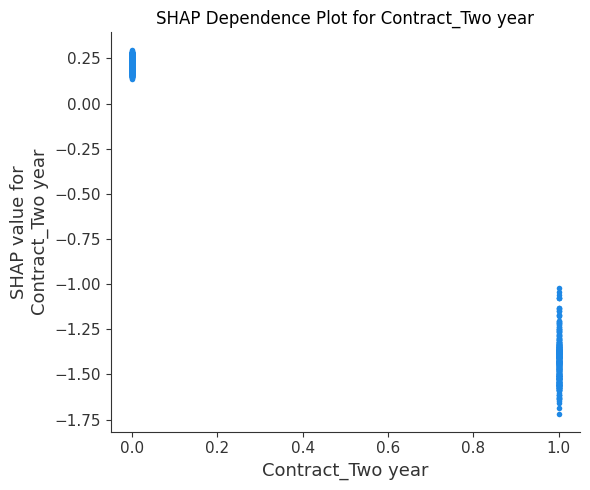

<Figure size 800x600 with 0 Axes>

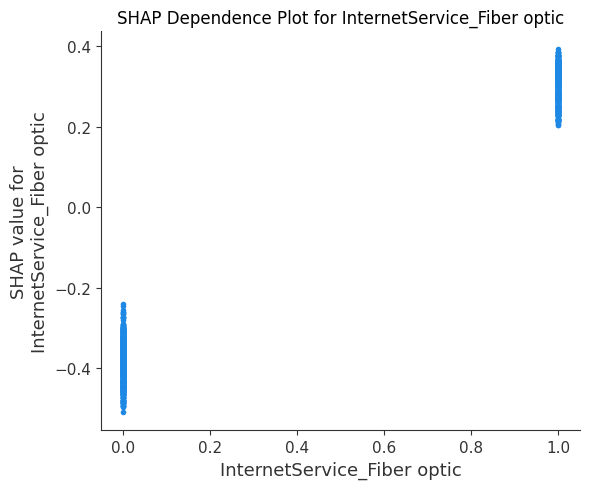

<Figure size 800x600 with 0 Axes>

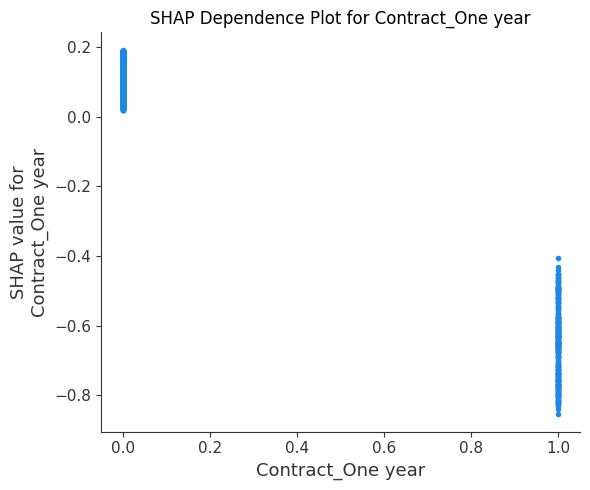

In [26]:
top_features = feature_importance_xgb['feature'].head(3).tolist()

print("Generating SHAP dependence plots for:", top_features)

for feature in top_features:
    plt.figure(figsize=(8, 6))
    shap.dependence_plot(feature, shap_values, X_test, interaction_index=None, show=False)
    plt.title(f"SHAP Dependence Plot for {feature}")
    plt.tight_layout()
    plt.show()